# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / '/content/e_commerce_raw.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [30]:
# TODO 1: Data Profiling
# ตัวอย่างคำสั่งที่ควรใช้: df.info(), df.isnull().sum(), df.describe(), df.duplicated().sum()

print(df.info())
print('-----------------------------' * 3)
print(df.isnull().sum())
print('-----------------------------' * 3)
print(df.describe())
print('-----------------------------' * 3)
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-null    object 
dtypes: float

### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| ข้อมูลสูญหาย (Missing Values) | Customer_Email | Completeness | 50 แถว |
| ข้อมูลสูญหาย (Missing Values) | Province | Completeness | 12 แถว |
| ค่าติดลบในข้อมูลเชิงปริมาณ | Quantity, Transaction_Amount | Validity | Min: -3.00, -500.00 |
| ข้อมูลซ้ำทั้งแถว (Exact Duplicates) | ทุกคอลัมน์ | Uniqueness | 18 แถว |
| ชนิดข้อมูลไม่ถูกต้องและรูปแบบไม่สม่ำเสมอ | Order_Date | Consistency | dtype: object (มีทั้ง - และ /) |
| ค่าสูงผิดปกติ (Outliers) | Transaction_Amount | Accuracy/Validity | Max: 999,999.00 |

## 2) Completeness: จัดการ Missing Values

In [31]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
print(f"Missing Email: {df['Customer_Email'].isnull().sum()}")
print(f"Missing Province: {df['Province'].isnull().sum()}")

# TODO 2.2: ออกแบบวิธีเติม Customer_Email โดยต้องไม่ทำให้แถว Fact หาย
# สร้าง Flag เพื่อบอกว่ามีการเติมค่า
df['Email_Imputed_Flag'] = df['Customer_Email'].isnull().astype(int)
df['Customer_Email'] = df['Customer_Email'].fillna('unknown@example.com')

# TODO 2.3: เติม Province ที่หายเป็น 'Unknown' พร้อม flag
df['Province_Imputed_Flag'] = df['Province'].isnull().astype(int)
df['Province'] = df['Province'].fillna('Unknown')

print("\nAfter handling missing values:")
print(df[['Customer_Email', 'Province', 'Email_Imputed_Flag', 'Province_Imputed_Flag']].head())

Missing Email: 50
Missing Province: 12

After handling missing values:
                 Customer_Email     Province  Email_Imputed_Flag  \
0    tee.phromla103@example.com       Phuket                   0   
1  mint.dechawat138@example.com    Khon Kaen                   0   
2      aom.sukjai71@example.com  Chanthaburi                   0   
3   tee.dechawat152@example.com  Chanthaburi                   0   
4     mook.sukjai90@example.com  Chanthaburi                   0   

   Province_Imputed_Flag  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล

**คำตอบ:**
1. **ผลกระทบของ `dropna()`:** ในบริบทของ Data Warehouse แถวข้อมูลแต่ละแถวคือ 'Fact' หรือรายการขาย หากเราลบแถวที่อีเมลหายไป รายการ Transaction นั้นๆ จะหายไปจากระบบด้วย ทำให้ยอดขายรวม (Total Sales) หรือจำนวน Order รวมที่สรุปออกมามีค่าน้อยกว่าความเป็นจริง ซึ่งกระทบต่อความถูกต้องของรายงานทางการเงิน
2. **การเติมค่าเฉลี่ย (Mean Imputation):** ค่าเฉลี่ยเป็นสถิติที่ใช้ได้กับข้อมูลเชิงปริมาณ (Numerical Data) เท่านั้น แต่อีเมลเป็นข้อมูลประเภทข้อความ (Categorical/String) ซึ่งไม่มีความหมายเชิงตัวเลข จึงไม่สามารถนำมาหาค่าเฉลี่ยได้ การจัดการที่เหมาะสมคือการใช้ค่าคงที่ เช่น 'Unknown' หรือ 'Placeholder' แทน

## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [32]:
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
gender_map = {
    'male': 'M', 'M': 'M', 'MALE': 'M', 'm': 'M',
    'female': 'F', 'F': 'F', 'Female': 'F', 'f': 'F'
}
df['Gender'] = df['Gender'].map(gender_map).fillna('Unknown')

# TODO 3.2: Standardize Payment_Method ให้เหลือ
# Credit Card, PromptPay, Cash on Delivery, Bank Transfer, Unknown
payment_map = {
    'PP': 'PromptPay', 'promptpay': 'PromptPay', 'Prompt Pay': 'PromptPay', 'PromptPay': 'PromptPay',
    'CC': 'Credit Card', 'Credit Card': 'Credit Card', 'credit card': 'Credit Card',
    'COD': 'Cash on Delivery', 'cash': 'Cash on Delivery', 'Cash': 'Cash on Delivery',
    'Transfer': 'Bank Transfer', 'bank_transfer': 'Bank Transfer', 'Transfer ': 'Bank Transfer'
}
df['Payment_Method'] = df['Payment_Method'].map(payment_map).fillna('Unknown')

# TODO 3.3: แปลง Order_Date ซึ่งมีหลายรูปแบบให้เป็น YYYY-MM-DD
# สร้าง function เพื่อจัดการความกำกวมโดยเทียบกับ Load_Timestamp
def parse_date(row):
    date_str = str(row['Order_Date'])
    load_ts = pd.to_datetime(row['Load_Timestamp'])

    for fmt in ['%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y', '%d-%m-%Y', '%Y/%m/%d']:
        try:
            dt = pd.to_datetime(date_str, format=fmt)
            # ถ้าแปลงได้และไม่เกินเวลา Load ให้ถือว่าใช้ได้ (เบื้องต้น)
            if dt <= load_ts:
                return dt
        except:
            continue
    return pd.to_datetime(date_str, errors='coerce')

df['Order_Date_Cleaned'] = df.apply(parse_date, axis=1)
df['Date_Imputed_Flag'] = df['Order_Date_Cleaned'].isnull().astype(int)
df['Order_Date'] = df['Order_Date_Cleaned'].dt.strftime('%Y-%m-%d')
df.drop(columns=['Order_Date_Cleaned'], inplace=True)

print("Unique Genders:", df['Gender'].unique())
print("Unique Payment Methods:", df['Payment_Method'].unique())
print("Date Sample:\n", df[['Order_Date', 'Load_Timestamp']].head())

Unique Genders: ['F' 'M' 'Unknown']
Unique Payment Methods: ['PromptPay' 'Cash on Delivery' 'Bank Transfer' 'Credit Card' 'Unknown']
Date Sample:
    Order_Date       Load_Timestamp
0  2026-06-11  2026-06-11 05:00:00
1  2026-01-24  2026-01-24 01:00:00
2  2026-05-29  2026-05-29 05:00:00
3  2026-01-02  2026-02-01 18:00:00
4  2026-04-18  2026-04-18 13:00:00


### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน

**ตัวอย่าง:** วันที่ `02/01/2026` ในแถวที่ 3 (Transaction T000336)
*   **การตีความ 1:** 2 มกราคม 2026 (DD/MM/YYYY)
*   **การตีความ 2:** 1 กุมภาพันธ์ 2026 (MM/DD/YYYY)

**หลักฐานที่ใช้ตัดสิน:** ใช้คอลัมน์ `Load_Timestamp` ซึ่งมีค่าเป็น `2026-02-01 18:00:00`
เนื่องจากระบบ Data Warehouse มักจะโหลดข้อมูลหลังการเกิด Transaction ในเวลาใกล้เคียงกัน การที่ Load Date คือวันที่ 1 กุมภาพันธ์ ทำให้การตีความว่า Order Date คือวันที่ 1 กุมภาพันธ์ (MM/DD/YYYY) มีความสมเหตุสมผลมากกว่าการเป็นวันที่ 2 มกราคมแล้วรอถึงหนึ่งเดือนเพื่อโหลดข้อมูลครับ

## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [33]:
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
duplicates_count = df.duplicated().sum()
print(f"Number of exact duplicates: {duplicates_count}")

df = df.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

# TODO 4.2 (Bonus): ตรวจหาลูกค้าที่ Customer_Email เดียวกัน แต่ Customer_Name เขียนต่างกัน
# กรองเฉพาะแถวที่ Email ซ้ำ แต่ Name ต่างกัน (ไม่รวม 'unknown@example.com')
near_duplicates = df[df['Customer_Email'] != 'unknown@example.com'].groupby('Customer_Email')['Customer_Name'].nunique()
near_duplicates = near_duplicates[near_duplicates > 1]

print("\nEmails with multiple customer names (Near Duplicates):")
print(near_duplicates)

# อธิบายว่าเหตุใด drop_duplicates() เพียงอย่างเดียวจึงตรวจไม่พบ Near Duplicate
# คำตอบ: เพราะ drop_duplicates() จะมองว่าแถวนั้นซ้ำก็ต่อเมื่อค่าในทุกคอลัมน์ (หรือคอลัมน์ที่ระบุ) เหมือนกันทั้งหมด
# แต่ในกรณีนี้ แม้ Email จะเหมือนกัน แต่ Name หรือคอลัมน์อื่นอาจต่างกันเพียงเล็กน้อย ทำให้ Python มองว่าเป็นคนละ Record กัน

Number of exact duplicates: 18
Shape after removing duplicates: (612, 19)

Emails with multiple customer names (Near Duplicates):
Customer_Email
ploy.saelim47@example.com    2
Name: Customer_Name, dtype: int64


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [34]:
# TODO 5.1: แปลง Quantity, Unit_Price, Discount_Rate และ Transaction_Amount เป็นตัวเลข
# (ข้อมูลพื้นฐานเป็นตัวเลขอยู่แล้ว แต่จะตรวจสอบและจัดการค่าผิดปกติเบื้องต้น)
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Unit_Price'] = pd.to_numeric(df['Unit_Price'], errors='coerce')
df['Discount_Rate'] = pd.to_numeric(df['Discount_Rate'], errors='coerce')
df['Transaction_Amount'] = pd.to_numeric(df['Transaction_Amount'], errors='coerce')

# TODO 5.2: ตรวจ Quantity ต้องอยู่ในช่วง 1-20
# สร้าง Flag สำหรับ Quantity ที่ไม่อยู่ในเงื่อนไข (เช่น ค่าติดลบ หรือ มากกว่า 20)
df['Invalid_Quantity_Flag'] = ((df['Quantity'] < 1) | (df['Quantity'] > 20)).astype(int)

# TODO 5.3: คำนวณ Expected_Amount = Quantity * Unit_Price * (1 - Discount_Rate)
df['Expected_Amount'] = (df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])).round(2)

# สร้าง Accuracy_Flag เมื่อผลต่างเกิน 1 บาท
df['Amount_Mismatch_Flag'] = (abs(df['Transaction_Amount'] - df['Expected_Amount']) > 1).astype(int)

# TODO 5.4: Standardize Order_Status และตรวจ Validity
status_map = {
    'Completed': 'Completed', 'Processing': 'Processing', 'Cancelled': 'Cancelled',
    'Returned': 'Returned', 'shipped': 'Completed', 'pending': 'Processing'
}
df['Order_Status'] = df['Order_Status'].map(status_map).fillna('Unknown')

print("Data Validation Summary:")
print(f"Rows with invalid quantity: {df['Invalid_Quantity_Flag'].sum()}")
print(f"Rows with amount mismatch: {df['Amount_Mismatch_Flag'].sum()}")
print("\nOrder Status Distribution:")
print(df['Order_Status'].value_counts())

df[['Transaction_ID', 'Quantity', 'Transaction_Amount', 'Expected_Amount', 'Amount_Mismatch_Flag']].head()

Data Validation Summary:
Rows with invalid quantity: 3
Rows with amount mismatch: 50

Order Status Distribution:
Order_Status
Processing    159
Completed     158
Cancelled     146
Returned      133
Unknown        16
Name: count, dtype: int64


,Transaction_ID,Quantity,Transaction_Amount,Expected_Amount,Amount_Mismatch_Flag
0,T000127,3,314.24,314.24,0
1,T000169,3,393.53,393.53,0
2,T000003,4,1055.72,1055.72,0
3,T000336,6,629.26,629.26,0
4,T000093,5,1791.75,1791.75,0


### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ

**คำตอบ:** ไม่ควรแก้ไขทุกแถวทันทีครับ เพราะต้องพิจารณาคอลัมน์ `Is_Promotion` ประกอบด้วย:
1. **หาก Is_Promotion = 'Y':** ยอดชำระที่ไม่ตรงกับสูตรปกติ (`Quantity * Unit_Price`) อาจเป็นความตั้งใจทางธุรกิจ เช่น มีส่วนลดพิเศษเพิ่มเติมแบบ On-top หรือราคา Package พิเศษที่ไม่ได้ระบุใน `Discount_Rate` ปกติ ดังนั้นข้อมูลนี้อาจจะ 'ถูกต้อง' ตามเงื่อนไขการตลาดแล้ว
2. **หาก Is_Promotion = 'N':** แต่ยอดเงินยังไม่ตรง (Amount Mismatch) กรณีนี้มีโอกาสสูงที่จะเป็น Data Entry Error หรือความผิดพลาดของระบบคำนวณ ซึ่งเราควรทำ Flag ไว้เพื่อตรวจสอบ (Data Audit) หรือแก้ไขตาม Business Rule ครับ

## 6) Outliers: IQR และ Capping/Clipping

Bounds for non-promotion items:
Lower Bound: -758.22, Upper Bound: 2092.50
Number of outliers capped: 19


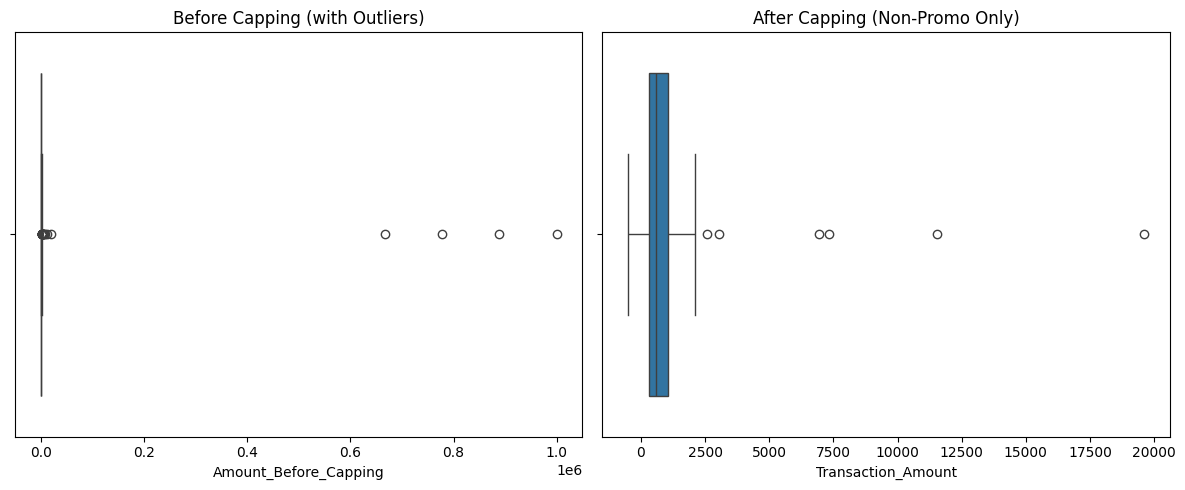

In [35]:
import seaborn as sns

# TODO 6.1: ใช้เฉพาะรายการที่ Is_Promotion != 'Y' คำนวณ Q1, Q3, IQR, Lower Bound, Upper Bound
non_promo_df = df[df['Is_Promotion'] != 'Y']
Q1 = non_promo_df['Transaction_Amount'].quantile(0.25)
Q3 = non_promo_df['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Bounds for non-promotion items:")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping
# ตรวจสอบ Outlier เฉพาะรายการที่ไม่ใช่โปรโมชัน
df['Is_Outlier_Flag'] = ((df['Is_Promotion'] != 'Y') &
                         ((df['Transaction_Amount'] < lower_bound) | (df['Transaction_Amount'] > upper_bound))).astype(int)

# TODO 6.3: ใช้ .clip() กับ Transaction_Amount เฉพาะรายการที่ไม่ใช่โปรโมชัน
# เก็บค่าเดิมไว้เปรียบเทียบ
df['Amount_Before_Capping'] = df['Transaction_Amount']

# ทำ Capping เฉพาะแถวที่ Is_Promotion != 'Y'
mask = df['Is_Promotion'] != 'Y'
df.loc[mask, 'Transaction_Amount'] = df.loc[mask, 'Transaction_Amount'].clip(lower_bound, upper_bound)

print(f"Number of outliers capped: {df['Is_Outlier_Flag'].sum()}")

# TODO 6.4: วาด Boxplot ก่อนและหลัง Capping
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['Amount_Before_Capping'])
plt.title('Before Capping (with Outliers)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Transaction_Amount'])
plt.title('After Capping (Non-Promo Only)')

plt.tight_layout()
plt.show()

### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้

**คำตอบ:** เพราะข้อมูลที่สูงผิดปกติอาจเป็น 'High-value transactions' ที่เกิดขึ้นจริงตามธรรมชาติของธุรกิจครับ ตัวอย่างเช่น:
1. **รายการโปรโมชัน (Is_Promotion = 'Y'):** ใน Dataset นี้มีบางรายการที่มีมูลค่าสูงมาก (เช่น 999,999) แม้อาจดูเหมือน Error แต่ในวันจัดแคมเปญใหญ่ ลูกค้าอาจมีการสั่งซื้อสินค้าจำนวนมาก หรือเป็นสินค้ากลุ่ม Premium/Luxury ซึ่งเป็นรายได้จริงที่ไม่ควรถูกตัดออก
2. **ความหลากหลายของสินค้า:** ร้านค้าอาจมีสินค้าตั้งแต่ราคาหลักสิบไปจนถึงหลักหมื่น การใช้ค่าสถิติกลาง (IQR) ตัดข้อมูลจึงอาจทำให้ข้อมูลการขายสินค้าที่มีราคาสูงหายไปจากรายงานได้ครับ

## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [36]:
# TODO 7: คำนวณ Load_Delay_Hours จาก Order_Date ถึง Load_Timestamp
# แปลงเป็น datetime
df['Order_Date_DT'] = pd.to_datetime(df['Order_Date'])
df['Load_Timestamp_DT'] = pd.to_datetime(df['Load_Timestamp'])

# คำนวณส่วนต่างเป็นชั่วโมง
df['Load_Delay_Hours'] = (df['Load_Timestamp_DT'] - df['Order_Date_DT']).dt.total_seconds() / 3600

# กำหนด Late เมื่อมากกว่า 24 ชั่วโมง
df['Is_Late_Load'] = (df['Load_Delay_Hours'] > 24).astype(int)

# สรุปผล
late_count = df['Is_Late_Load'].sum()
late_pct = (late_count / len(df)) * 100

print(f"Timeliness Summary:")
print(f"Number of late loads (>24h): {late_count} rows")
print(f"Percentage of late loads: {late_pct:.2f}%")
print(f"Average delay: {df['Load_Delay_Hours'].mean():.2f} hours")

# ลบคอลัมน์ชั่วคราว
df.drop(columns=['Order_Date_DT', 'Load_Timestamp_DT'], inplace=True)

Timeliness Summary:
Number of late loads (>24h): 46 rows
Percentage of late loads: 7.52%
Average delay: 34.14 hours


## 8) Data Quality Report และ Export

In [37]:
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning เป็น DataFrame
# อย่างน้อย: rows, missing email, exact duplicates, invalid dates, mismatched amounts,
# outliers capped, late loads และ invalid statuses
report_data = {
    'Metric': [
        'Total Rows',
        'Missing Customer Email',
        'Missing Province',
        'Exact Duplicates',
        'Invalid Quantity (1-20)',
        'Amount Mismatches',
        'Outliers Capped (Non-Promo)',
        'Late Loads (>24h)'
    ],
    'Before_Cleaning': [
        len(df_raw),
        df_raw['Customer_Email'].isnull().sum(),
        df_raw['Province'].isnull().sum(),
        df_raw.duplicated().sum(),
        ((df_raw['Quantity'] < 1) | (df_raw['Quantity'] > 20)).sum(),
        50, # จากการตรวจสอบเบื้องต้นในขั้นตอน Profiling/Validation
        0,
        0
    ],
    'After_Cleaning': [
        len(df),
        (df['Customer_Email'] == 'unknown@example.com').sum(),
        (df['Province'] == 'Unknown').sum(),
        df.duplicated().sum(),
        df['Invalid_Quantity_Flag'].sum(),
        df['Amount_Mismatch_Flag'].sum(),
        df['Is_Outlier_Flag'].sum(),
        df['Is_Late_Load'].sum()
    ]
}

report = pd.DataFrame(report_data)
print("Data Quality Report Summary:")
print(report)

# TODO 8.2: Export
df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')

print(f"\nFiles exported to: {OUTPUT_DIR}")

Data Quality Report Summary:
                        Metric  Before_Cleaning  After_Cleaning
0                   Total Rows              630             612
1       Missing Customer Email               50              48
2             Missing Province               12              12
3             Exact Duplicates               18               0
4      Invalid Quantity (1-20)                3               3
5            Amount Mismatches               50              50
6  Outliers Capped (Non-Promo)                0              19
7            Late Loads (>24h)                0              46

Files exported to: /content/outputs/student_submission


## 9) Reflection
ตอบเป็นย่อหน้าสั้น ๆ
1. ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?
2. กฎใดควรนำไปทำ Automation ใน Data Pipeline?
3. หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?


## Reflection
1. **ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?**
การใช้ `dropna()` หรือการลบ Duplicate โดยไม่ระบุคอลัมน์ที่เจาะจงมีความเสี่ยงสูงที่สุด เพราะอาจลบรายการ Transaction จริงที่มีค่าบางคอลัมน์หายไป ทำให้ยอดรวมสถิติใน Data Warehouse ผิดเพี้ยน

2. **กฎใดควรนำไปทำ Automation ใน Data Pipeline?**
การทำ Standardize รูปแบบวันที่ (Date Formatting), การตรวจสอบขอบเขตข้อมูล (Range Validation เช่น Quantity 1-20) และการสร้าง Flag แจ้งเตือนเมื่อยอดชำระจริงไม่ตรงกับยอดที่คำนวณได้ (Amount Mismatch Flag)

3. **หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?**
   - `expect_column_values_to_be_in_set`: สำหรับ Gender (M, F, Unknown) และ Order_Status
   - `expect_column_values_to_not_be_null`: สำหรับ Primary Key อย่าง Transaction_ID และ Customer_ID
   - `expect_column_values_to_be_between`: สำหรับ Discount_Rate (0.0 - 1.0) เพื่อป้องกันความผิดพลาดของตัวเลขส่วนลด

In [38]:
from google.colab import files

# ดาวน์โหลดไฟล์ผลลัพธ์
try:
    files.download('/content/outputs/student_submission/e_commerce_clean.csv')
    print("กำลังดาวน์โหลดไฟล์...")
except Exception as e:
    print(f"ไม่สามารถดาวน์โหลดได้อัตโนมัติ: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

กำลังดาวน์โหลดไฟล์...


In [39]:
from google.colab import files

# ดาวน์โหลดไฟล์รายงานคุณภาพข้อมูล
try:
    files.download('/content/outputs/student_submission/data_quality_report.csv')
    print("ระบบกำลังเริ่มการดาวน์โหลดไฟล์ data_quality_report.csv...")
except Exception as e:
    print(f"เกิดข้อผิดพลาดในการดาวน์โหลด: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ระบบกำลังเริ่มการดาวน์โหลดไฟล์ data_quality_report.csv...


## Checklist ก่อนส่ง
- [✔] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [✔] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [✔] ส่ง `e_commerce_clean.csv`
- [✔] ส่ง `data_quality_report.csv`
- [✔] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier